In [12]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [13]:
%ls

 Volume in drive C has no label.
 Volume Serial Number is 4CC7-BD53

 Directory of c:\Users\sami\OneDrive\Desktop\AI4B Week 2\spaceship-titanic

01/12/2026  09:05 AM    <DIR>          .
01/12/2026  08:40 AM    <DIR>          ..
01/12/2026  08:57 AM    <DIR>          eda_results
01/12/2026  08:39 AM            59,902 sample_submission.csv
01/12/2026  09:20 AM            61,881 submission.csv
01/12/2026  08:39 AM           372,487 test.csv
01/12/2026  08:39 AM           805,421 train.csv
01/12/2026  09:49 AM            43,296 train_and _testing.ipynb
               5 File(s)      1,342,987 bytes
               3 Dir(s)  10,463,150,080 bytes free


In [14]:
train_path = 'train.csv'
test_path = 'test.csv'

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print(f"Train loaded with shape: {train_df.shape}")
print(f"Test loaded with shape: {test_df.shape}")

Train loaded with shape: (8693, 14)
Test loaded with shape: (4277, 13)


In [15]:
print(train_df.info())
print(train_df.isnull().sum())
print(train_df.describe())
print(train_df['Transported'].value_counts(normalize=True))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB
None
PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             2


 EDA


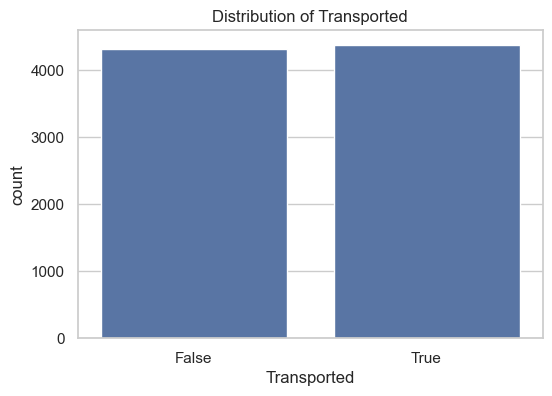

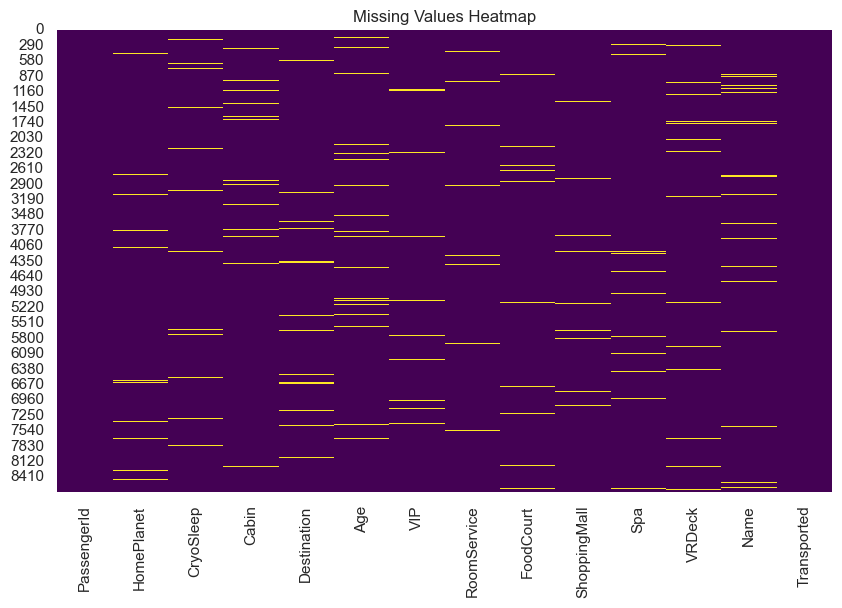

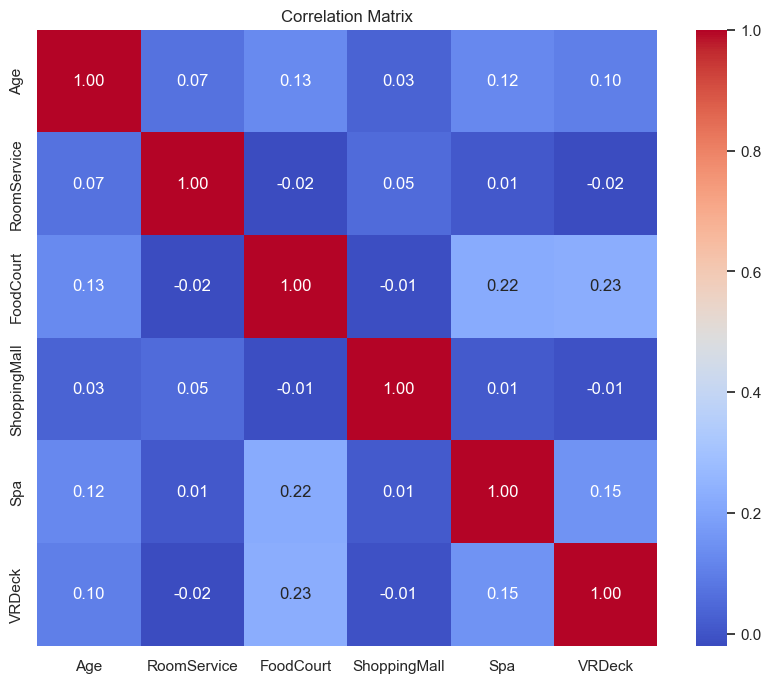

In [16]:
print("\n EDA")

# Target Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='Transported', data=train_df)
plt.title('Distribution of Transported')
plt.show()  

# Missing Values Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(train_df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()  

# Correlation Matrix
numeric_cols = train_df.select_dtypes(include=[np.number]).columns
if len(numeric_cols) > 0:
    plt.figure(figsize=(10, 8))
    sns.heatmap(train_df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
    plt.title('Correlation Matrix')
    plt.show() 


In [17]:
print("\nProcessing data...")

# Combine to process together
train_df['dataset'] = 'train'
test_df['dataset'] = 'test'
df = pd.concat([train_df, test_df], sort=False).reset_index(drop=True)

# Feature Engineering
if 'Cabin' in df.columns:
    df[['Deck', 'num', 'Side']] = df['Cabin'].str.split('/', expand=True)
    df = df.drop(['Cabin', 'Name', 'num'], axis=1)

# Fill Missing Values
cat_cols = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Deck', 'Side']
for c in cat_cols:
    if c in df.columns:
        df[c] = df[c].fillna(df[c].mode()[0])

num_cols = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
for c in num_cols:
    if c in df.columns:
        df[c] = df[c].fillna(df[c].median())

# Encoding
for c in ['CryoSleep', 'VIP']:
    if c in df.columns:
        df[c] = df[c].astype(bool).astype(int)

df = pd.get_dummies(df, columns=['HomePlanet', 'Destination', 'Deck', 'Side'], drop_first=True)

# Split back to train/test
train_clean = df[df['dataset'] == 'train'].drop('dataset', axis=1)
test_clean = df[df['dataset'] == 'test'].drop(['dataset', 'Transported'], axis=1)

# Fix target column in train
if 'Transported' in train_clean.columns:
    train_clean['Transported'] = train_clean['Transported'].astype(int)

print("Done! Data processed.")
print(f"Processed Train Shape: {train_clean.shape}")
print(f"Processed Test Shape: {test_clean.shape}")

train_clean.to_csv(os.path.join(output_dir, 'train_processed.csv'), index=False)
test_clean.to_csv(os.path.join(output_dir, 'test_processed.csv'), index=False)



Processing data...


C:\Users\sami\AppData\Local\Temp\ipykernel_4984\254599674.py:17: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[c] = df[c].fillna(df[c].mode()[0])


Done! Data processed.
Processed Train Shape: (8693, 22)
Processed Test Shape: (4277, 21)


Model Training  

In [18]:
# Load processed data
try:
    train_df = pd.read_csv(os.path.join('eda_results', 'train_processed.csv'))
    test_df = pd.read_csv(os.path.join('eda_results', 'test_processed.csv'))
except FileNotFoundError:
    train_df = pd.read_csv('train_processed.csv')
    test_df = pd.read_csv('test_processed.csv')

print(f"Train Shape: {train_df.shape}")
print(f"Test Shape: {test_df.shape}")

X = train_df.drop('Transported', axis=1)
y = train_df['Transported']

# Align columns
for col in X.columns:
    if col not in test_df.columns:
        test_df[col] = 0
test_X = test_df[X.columns]

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# GridSearch and Training
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}
grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=3, n_jobs=-1)
grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_val)

Train Shape: (8693, 22)
Test Shape: (4277, 21)


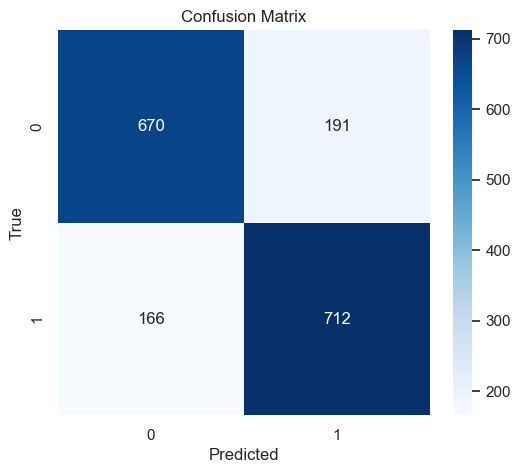

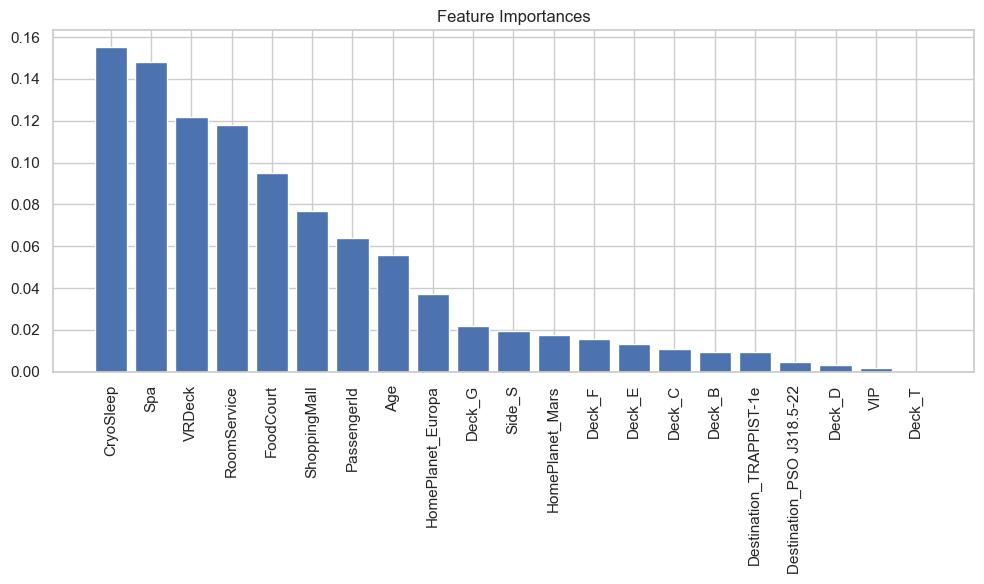

In [20]:
# Plots
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_val, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.show()

importances = best_rf.feature_importances_
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(10, 6))
plt.title("Feature Importances")
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), X.columns[indices], rotation=90)
plt.tight_layout()
plt.show()


  saving  

In [21]:
# Predictions and Submission
final_preds = best_rf.predict(test_X)
output = pd.DataFrame({'Transported': final_preds.astype(bool)})

# Restore PassengerId
if 'PassengerId' in test_df.columns:
    output.insert(0, 'PassengerId', test_df['PassengerId'])
else:
    # Try getting original if not in test_df
    if os.path.exists('test.csv'):
        original_test = pd.read_csv('test.csv')
        output.insert(0, 'PassengerId', original_test['PassengerId'])
    elif os.path.exists(os.path.join('spaceship-titanic', 'test.csv')):
        original_test = pd.read_csv(os.path.join('spaceship-titanic', 'test.csv'))
        output.insert(0, 'PassengerId', original_test['PassengerId'])
    else:
        output.insert(0, 'PassengerId', test_df.index)

submission_path = 'submission.csv'
if os.path.exists('eda_results'):
    submission_path = os.path.join('eda_results', 'submission.csv')

output.to_csv(submission_path, index=False)
print(f"Submission saved to {submission_path}")


Submission saved to eda_results\submission.csv
